In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls"/content/drive/My Drive"

/bin/bash: line 1: ls/content/drive/My Drive: No such file or directory


In [ ]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.image import imread
import random
from os import listdir
from sklearn.preprocessing import LabelBinarizer
from keras.preprocessing import image
from keras.preprocessing.image import img_to_array, array_to_img
from keras.optimizers import Adam
from PIL import Image
from keras.models import Sequential
from keras.layers import BatchNormalization  # ✅ updated line
from keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dropout, Dense, LeakyReLU
from sklearn.model_selection import train_test_split


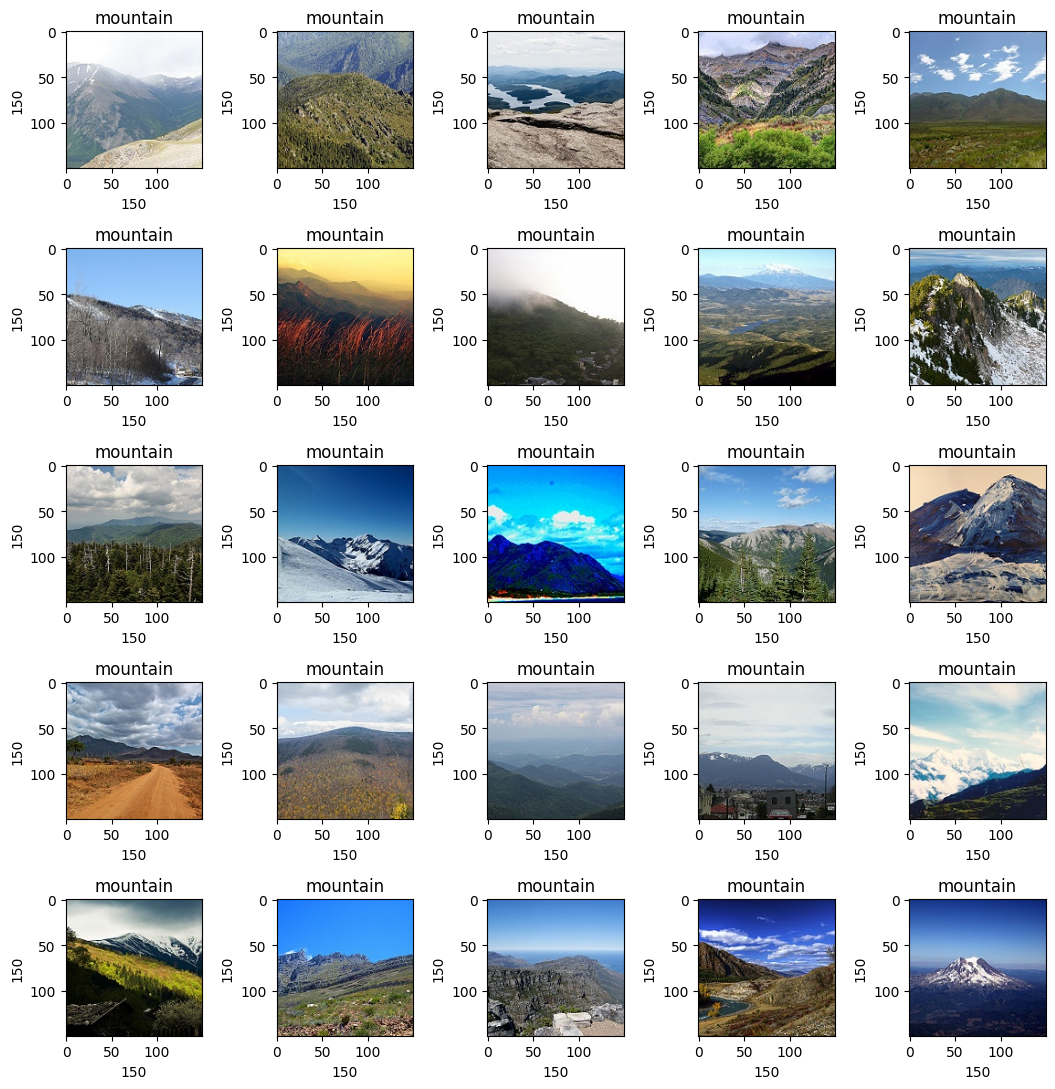

In [ ]:
plt.figure(figsize=(11,11))
path = "/content/drive/My Drive/Intel Image Dataset/mountain"
for i in range(1,26):
    plt.subplot(5,5,i)
    plt.tight_layout()
    rand_img = imread(path +'/'+ random.choice(sorted(listdir(path))))
    plt.imshow(rand_img)
    plt.title('mountain')
    plt.xlabel(rand_img.shape[1], fontsize = 10)
    plt.ylabel(rand_img.shape[0], fontsize = 10)

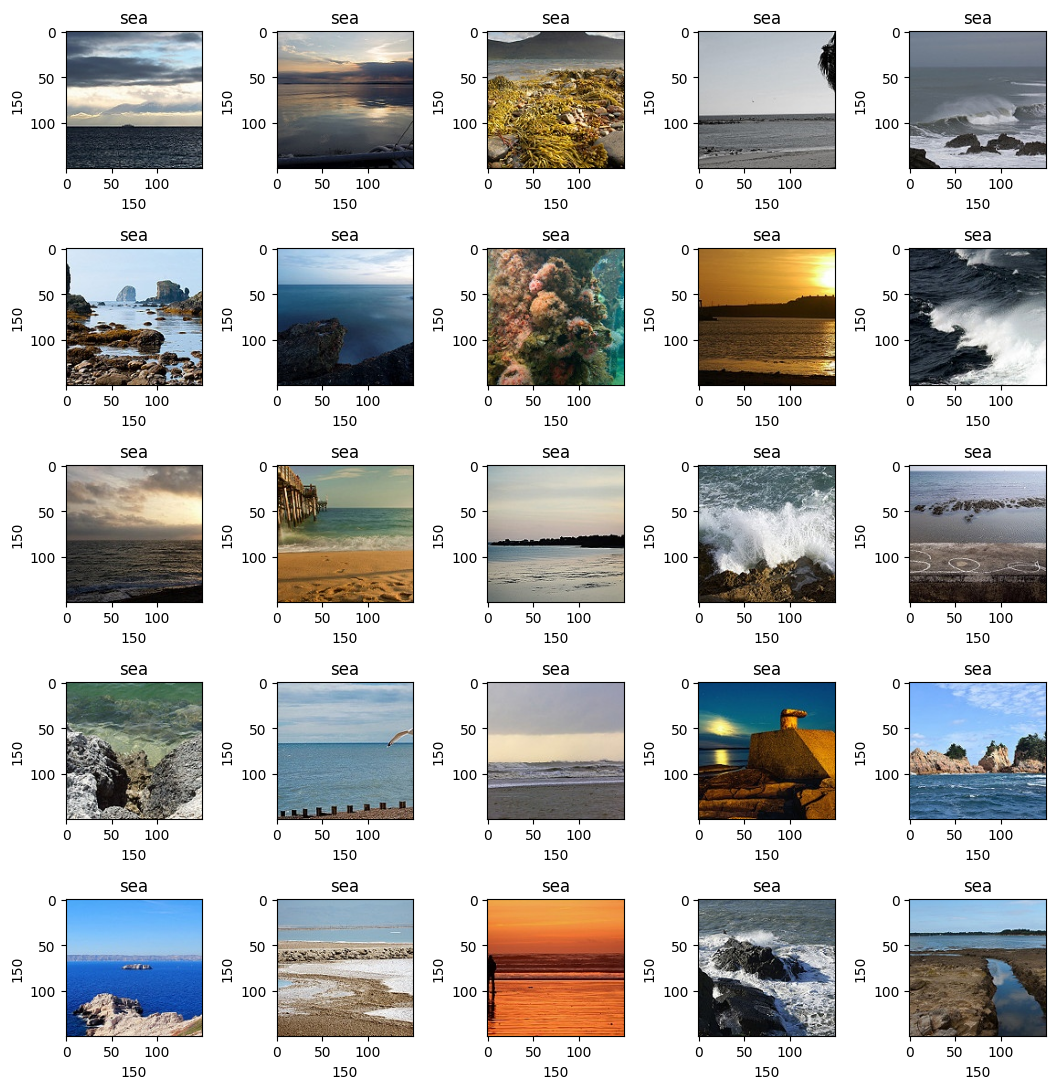

In [ ]:
plt.figure(figsize=(11,11))
path = "/content/drive/My Drive/Intel Image Dataset/sea"
for i in range(1,26):
    plt.subplot(5,5,i)
    plt.tight_layout()
    rand_img = imread(path +'/'+ random.choice(sorted(listdir(path))))
    plt.imshow(rand_img)
    plt.title('sea')
    plt.xlabel(rand_img.shape[1], fontsize = 10)
    plt.ylabel(rand_img.shape[0], fontsize = 10)

In [ ]:
dir="/content/drive/My Drive/Intel Image Dataset"
root_dir=listdir(dir)
image_lisr,label_lisr=[],[]

In [ ]:
from os import listdir
from PIL import Image
from tensorflow.keras.preprocessing.image import img_to_array

image_list = []
label_list = []

for directory in root_dir:
    for files in listdir(f"{dir}/{directory}"):
        image_path = f"{dir}/{directory}/{files}"
        image = Image.open(image_path)
        image = image.resize((150, 150))  # ✅ Corrected line
        image = img_to_array(image)
        image_list.append(image)
        label_list.append(directory)



In [ ]:
label_counts=pd.DataFrame(label_list).value_counts()
label_counts

,count
0,
glacier,553
mountain,525
sea,510
street,501
forest,474
buildings,437


In [ ]:
num_classes=len(label_counts)
num_classes

6

In [ ]:
np.array(image_list).shape

(3000, 150, 150, 3)

In [ ]:
label_list=np.array(label_list)
label_list.shape

(3000,)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(image_list,label_list,test_size=0.2,random_state=10)

In [ ]:
x_train=np.array(x_train,dtype=np.float16)/225.0
x_test=np.array(x_test,dtype=np.float16)/225.0
x_train=x_train.reshape(-1,150,150,3)
x_test=x_test.reshape(-1,150,150,3)

In [ ]:
lb=LabelBinarizer()
y_train=lb.fit_transform(y_train)
y_test=lb.fit_transform(y_test)
print(lb.classes_)

['buildings' 'forest' 'glacier' 'mountain' 'sea' 'street']


In [ ]:
x_train,x_val,y_train,y_val=train_test_split(x_train,y_train,test_size=0.2)

In [ ]:
model=Sequential([
    Conv2D(16,kernel_size=(3,3),input_shape=(150,150,3)),
    BatchNormalization(),
    LeakyReLU(),

    Conv2D(32,kernel_size=(3,3)),
    BatchNormalization(),
    LeakyReLU(),
    MaxPooling2D(5,5),

    Conv2D(64,kernel_size=(3,3)),
    BatchNormalization(),
    LeakyReLU(),

    Conv2D(128,kernel_size=(3,3)),
    BatchNormalization(),
    LeakyReLU(),
    MaxPooling2D(5,5),

    Flatten(),

    Dense(64),
    Dropout(rate=0.2),
    BatchNormalization(),
    LeakyReLU(),

    Dense(32),
    Dropout(rate=0.2),
    BatchNormalization(),
    LeakyReLU(),

    Dense(16),
    Dropout(rate=0.2),
    BatchNormalization(),
    LeakyReLU(1),

    Dense(6,activation='softmax')







])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 148, 148, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 146, 146, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 146, 146, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 146, 146, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 29, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 27, 27, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 27, 27, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 27, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │             

 Total params: 306,422 (1.17 MB)

 Trainable params: 305,718 (1.17 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer=Adam(0.0005),metrics=['accuracy'])

In [ ]:
epochs=70
batch_size=128
history=model.fit(x_train,y_train,batch_size,epochs=epochs,validation_data=(x_val,y_val))

Epoch 1/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 147s 9s/step - accuracy: 0.3452 - loss: 1.7664 - val_accuracy: 0.2542 - val_loss: 1.7797
Epoch 2/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 146s 10s/step - accuracy: 0.5584 - loss: 1.2220 - val_accuracy: 0.1896 - val_loss: 1.8977
Epoch 3/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 141s 9s/step - accuracy: 0.6408 - loss: 1.0363 - val_accuracy: 0.1917 - val_loss: 2.0081
Epoch 4/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 137s 9s/step - accuracy: 0.6911 - loss: 0.9516 - val_accuracy: 0.1917 - val_loss: 1.9634
Epoch 5/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 138s 9s/step - accuracy: 0.7556 - loss: 0.8026 - val_accuracy: 0.1917 - val_loss: 2.0120
Epoch 6/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 136s 9s/step - accuracy: 0.7716 - loss: 0.7369 - val_accuracy: 0.2042 - val_loss: 2.0674
Epoch 7/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 150s 10s/step - accuracy: 0.7947 - loss: 0.7018 - val_accuracy: 0.1896 - val_loss: 2.0584
Epoch 8/70
15/15 ━━━━━━━━━━━━━━━━━━━━ 194s 9s/step - accuracy: 0.8104 - loss: 0.6145 - val_accuracy: 0.1896 -

In [22]:
model.save("/content/drive/My Drive/intel_image.h5")

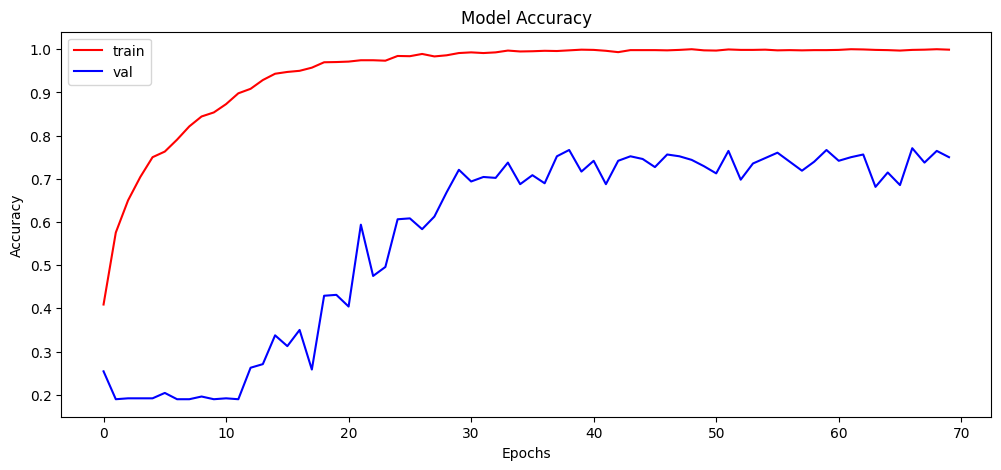

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], color='r')
plt.plot(history.history['val_accuracy'], color='b')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'val'])
plt.show()

In [24]:
scores=model.evaluate(x_test,y_test)
print(f"Test Accuracy:  {scores[1]*100}")


19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 851ms/step - accuracy: 0.7376 - loss: 0.8818
Test Accuracy:  75.3333330154419


In [26]:
y_pred=model.predict(x_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 479ms/step


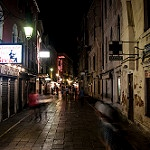

In [27]:
img=array_to_img(x_test[1])
img

In [28]:
labels=lb.classes_
print(labels)
print("Originally :",labels[np.argmax(y_test[1])])
print("Predicted :",labels[np.argmax(y_pred[1])])

['buildings' 'forest' 'glacier' 'mountain' 'sea' 'street']
Originally : street
Predicted : street


In [29]:
model.save("/content/drive/My Drive/intel_image.h5")